In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cryptography.hazmat.primitives.asymmetric import rsa, padding
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.backends import default_backend
from kyber_py.kyber import Kyber512, Kyber768, Kyber1024

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
key_sizes = [1024, 2048, 4096]
rsa_results = []

for size in key_sizes:
    start = time.time()
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=size,
        backend=default_backend()
    )
    elapsed = time.time() - start
    
    public_key = private_key.public_key()
    
    rsa_results.append({
        'key_size': size,
        'keygen_time': elapsed,
        'public_key_bits': size,
    })
    print(f"RSA-{size}: {elapsed:.4f}s")

RSA-1024: 0.0714s
RSA-2048: 0.0358s
RSA-4096: 0.4347s


In [3]:
message = b"Sensitive data requiring quantum-resistant protection."

for result in rsa_results:
    size = result['key_size']
    
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=size,
        backend=default_backend()
    )
    public_key = private_key.public_key()
    
    start = time.time()
    ciphertext = public_key.encrypt(
        message,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    result['encrypt_time'] = time.time() - start
    
    start = time.time()
    plaintext = private_key.decrypt(
        ciphertext,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    result['decrypt_time'] = time.time() - start
    
    print(f"RSA-{size} | encrypt: {result['encrypt_time']:.6f}s | decrypt: {result['decrypt_time']:.6f}s")

RSA-1024 | encrypt: 0.001493s | decrypt: 0.000633s
RSA-2048 | encrypt: 0.000158s | decrypt: 0.000998s
RSA-4096 | encrypt: 0.000141s | decrypt: 0.004026s


In [4]:
kyber_variants = [
    ('Kyber512',  Kyber512),
    ('Kyber768',  Kyber768),
    ('Kyber1024', Kyber1024),
]

kyber_results = []

for name, kyber in kyber_variants:
    start = time.time()
    public_key, private_key = kyber.keygen()
    keygen_time = time.time() - start
    
    start = time.time()
    key, ciphertext = kyber.encaps(public_key)
    enc_time = time.time() - start
    
    start = time.time()
    decoded_key = kyber.decaps(private_key, ciphertext)
    dec_time = time.time() - start
    
    kyber_results.append({
        'variant': name,
        'keygen_time': keygen_time,
        'enc_time': enc_time,
        'dec_time': dec_time,
        'public_key_bytes': len(public_key),
        'ciphertext_bytes': len(ciphertext),
    })
    
    print(f"{name} | keygen: {keygen_time:.6f}s | enc: {enc_time:.6f}s | dec: {dec_time:.6f}s | pk: {len(public_key)}B | ct: {len(ciphertext)}B")

Kyber512 | keygen: 0.005800s | enc: 0.005426s | dec: 0.006077s | pk: 800B | ct: 768B
Kyber768 | keygen: 0.008284s | enc: 0.005849s | dec: 0.015525s | pk: 1184B | ct: 1088B
Kyber1024 | keygen: 0.010015s | enc: 0.004668s | dec: 0.005847s | pk: 1568B | ct: 1568B


In [5]:
df_rsa = pd.DataFrame(rsa_results)
df_kyber = pd.DataFrame(kyber_results)

decrypt_times = df_rsa['decrypt_time'].values
key_sizes_arr = df_rsa['key_size'].values

coeficientes = []
for i in range(1, len(decrypt_times)):
    ratio_time = decrypt_times[i] / decrypt_times[i-1]
    ratio_key  = key_sizes_arr[i] / key_sizes_arr[i-1]
    coef = ratio_time / ratio_key
    coeficientes.append({
        'transition': f"RSA-{key_sizes_arr[i-1]} → RSA-{key_sizes_arr[i]}",
        'key_ratio': ratio_key,
        'time_ratio': round(ratio_time, 4),
        'growth_coefficient': round(coef, 4)
    })

df_coef = pd.DataFrame(coeficientes)
print("RSA Decryption Growth Coefficient:")
print(df_coef.to_string(index=False))

RSA Decryption Growth Coefficient:
         transition  key_ratio  time_ratio  growth_coefficient
RSA-1024 → RSA-2048        2.0      1.5774              0.7887
RSA-2048 → RSA-4096        2.0      4.0325              2.0162


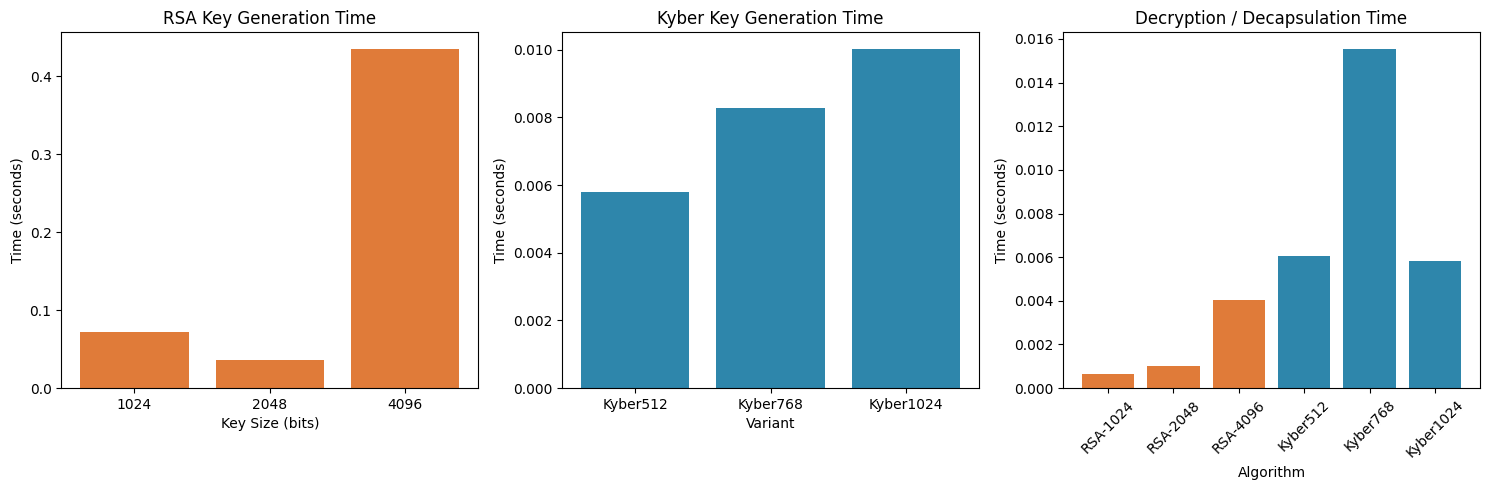

Chart saved to docs/performance_comparison.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar([str(s) for s in df_rsa['key_size']], 
            df_rsa['keygen_time'], color='#E07B39')
axes[0].set_title('RSA Key Generation Time')
axes[0].set_xlabel('Key Size (bits)')
axes[0].set_ylabel('Time (seconds)')

axes[1].bar(df_kyber['variant'], 
            df_kyber['keygen_time'], color='#2E86AB')
axes[1].set_title('Kyber Key Generation Time')
axes[1].set_xlabel('Variant')
axes[1].set_ylabel('Time (seconds)')

rsa_labels = [f"RSA-{s}" for s in df_rsa['key_size']]
kyber_labels = list(df_kyber['variant'])
all_labels = rsa_labels + kyber_labels
all_times = list(df_rsa['decrypt_time']) + list(df_kyber['dec_time'])
bar_colors = ['#E07B39']*3 + ['#2E86AB']*3

axes[2].bar(all_labels, all_times, color=bar_colors)
axes[2].set_title('Decryption / Decapsulation Time')
axes[2].set_xlabel('Algorithm')
axes[2].set_ylabel('Time (seconds)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to docs/performance_comparison.png")

In [7]:
print("=" * 55)
print("POST-QUANTUM RISK ANALYSIS — SUMMARY")
print("=" * 55)

print("\nRSA Performance:")
for r in rsa_results:
    print(f"  RSA-{r['key_size']} | keygen: {r['keygen_time']:.4f}s | "
          f"encrypt: {r['encrypt_time']:.6f}s | decrypt: {r['decrypt_time']:.6f}s")

print("\nKyber Performance:")
for r in kyber_results:
    print(f"  {r['variant']} | keygen: {r['keygen_time']:.6f}s | "
          f"enc: {r['enc_time']:.6f}s | dec: {r['dec_time']:.6f}s | "
          f"pk: {r['public_key_bytes']}B | ct: {r['ciphertext_bytes']}B")

print("\nRSA Decryption Growth Coefficient:")
print(df_coef.to_string(index=False))

print("\nKey Finding:")
print("  Doubling RSA key size does NOT double decryption time.")
print("  Growth is superlinear — making RSA scaling an")
print("  unsustainable defense against quantum threats.")
print("  Post-quantum migration (Kyber) is the viable path.")
print("=" * 55)

POST-QUANTUM RISK ANALYSIS — SUMMARY

RSA Performance:
  RSA-1024 | keygen: 0.0714s | encrypt: 0.001493s | decrypt: 0.000633s
  RSA-2048 | keygen: 0.0358s | encrypt: 0.000158s | decrypt: 0.000998s
  RSA-4096 | keygen: 0.4347s | encrypt: 0.000141s | decrypt: 0.004026s

Kyber Performance:
  Kyber512 | keygen: 0.005800s | enc: 0.005426s | dec: 0.006077s | pk: 800B | ct: 768B
  Kyber768 | keygen: 0.008284s | enc: 0.005849s | dec: 0.015525s | pk: 1184B | ct: 1088B
  Kyber1024 | keygen: 0.010015s | enc: 0.004668s | dec: 0.005847s | pk: 1568B | ct: 1568B

RSA Decryption Growth Coefficient:
         transition  key_ratio  time_ratio  growth_coefficient
RSA-1024 → RSA-2048        2.0      1.5774              0.7887
RSA-2048 → RSA-4096        2.0      4.0325              2.0162

Key Finding:
  Doubling RSA key size does NOT double decryption time.
  Growth is superlinear — making RSA scaling an
  unsustainable defense against quantum threats.
  Post-quantum migration (Kyber) is the viable path.
